In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D, Flatten
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow import keras

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, _), (x_test, _) = cifar10.load_data()

170498071/170498071 [==============================] - 4s 0us/step


In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
x_train = np.reshape(x_train, (-1, x_train.shape[1], x_train.shape[1]))
x_test = np.reshape(x_test, (-1, x_test.shape[1], x_test.shape[1]))
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [ ]:
input_shape = (32, 32, 3)
batch_size = 32
kernel_size = 3

In [ ]:
inputs = Input(shape=input_shape)
x = inputs
x = Conv2D(filters=32, kernel_size=kernel_size, activation='relu', strides=1,)(x)
x = Conv2D(filters=64, kernel_size=kernel_size, activation='relu', strides=1, )(x)
x = Conv2D(filters=128, kernel_size=kernel_size, activation='relu', strides=1)(x)
shape = K.int_shape(x)
x = Flatten()(x)
h = Dense(10)(x)

encoder = Model(inputs, h)

In [ ]:
encoder.summary()

Model: "model_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 conv2d_10 (Conv2D)          (None, 28, 28, 64)        18496     
                                                                 
 conv2d_11 (Conv2D)          (None, 26, 26, 128)       73856     
                                                                 
 flatten_3 (Flatten)         (None, 86528)             0         
                                                                 
 dense_12 (Dense)            (None, 10)                865290    
                                                                 
Total params: 958,538
Trainable params: 958,538
Non-traina

In [ ]:
h_inputs = Input(shape=10)
x = Dense(shape[1] * shape[2] * shape[3])(h_inputs)
x = Reshape((shape[1], shape[2], shape[3]))(x)
x = Conv2DTranspose(filters=64, kernel_size=kernel_size, activation='relu', strides=1)(x)
x = Conv2DTranspose(filters=32, kernel_size=kernel_size, activation='relu', strides=1)(x)
outputs = Conv2DTranspose(filters=3, kernel_size=kernel_size, activation='sigmoid', strides=1, )(x)

decoder = Model(h_inputs, outputs)

In [ ]:
decoder.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 10)]              0         
                                                                 
 dense_14 (Dense)            (None, 86528)             951808    
                                                                 
 reshape_10 (Reshape)        (None, 26, 26, 128)       0         
                                                                 
 conv2d_transpose_30 (Conv2D  (None, 28, 28, 64)       73792     
 Transpose)                                                      
                                                                 
 conv2d_transpose_31 (Conv2D  (None, 30, 30, 32)       18464     
 Transpose)                                                      
                                                                 
 conv2d_transpose_32 (Conv2D  (None, 32, 32, 3)        867

In [ ]:
autoencoder = Model(inputs, decoder(encoder(inputs)))
autoencoder.summary()

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 32, 32, 3)]       0         
                                                                 
 model_13 (Functional)       (None, 10)                958538    
                                                                 
 model_15 (Functional)       (None, 32, 32, 3)         1044931   
                                                                 
Total params: 2,003,469
Trainable params: 2,003,469
Non-trainable params: 0
_________________________________________________________________


In [ ]:
autoencoder.compile(loss='mse', optimizer='adam')

In [ ]:
autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=10, batch_size=batch_size)

Epoch 1/10
1563/1563 [==============================] - 1072s 685ms/step - loss: 18445.4805 - val_loss: 18631.3223
Epoch 2/10
1563/1563 [==============================] - 1049s 671ms/step - loss: 18445.3711 - val_loss: 18631.3223
Epoch 3/10
1563/1563 [==============================] - 1045s 668ms/step - loss: 18445.3789 - val_loss: 18631.3223
Epoch 4/10
1563/1563 [==============================] - 1081s 691ms/step - loss: 18445.3809 - val_loss: 18631.3223
Epoch 5/10
1563/1563 [==============================] - 1113s 712ms/step - loss: 18445.3848 - val_loss: 18631.3223
Epoch 6/10
1563/1563 [==============================] - 1073s 686ms/step - loss: 18445.3691 - val_loss: 18631.3223
Epoch 7/10
1563/1563 [==============================] - 1047s 670ms/step - loss: 18445.3691 - val_loss: 18631.3223
Epoch 8/10
1563/1563 [==============================] - 1031s 659ms/step - loss: 18445.3691 - val_loss: 18631.3223
Epoch 9/10
1563/1563 [==============================] - 995s 637ms/step - loss: 

In [ ]:
x_decoded = autoencoder.predict(x_test)

313/313 [==============================] - 2s 7ms/step


<ipython-input-15-baf348a69cc2>:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(2,4,1)


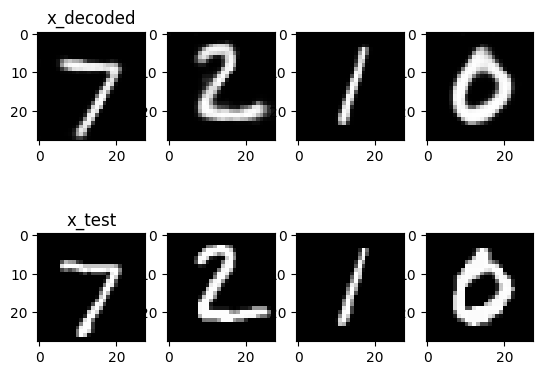

In [ ]:
plt.figure()
plt.title("x_decode")
ax1 = plt.subplot(2,4,1)
ax1.title.set_text('x_decoded')
plt.imshow(x_decoded[0], cmap='gray')
plt.subplot(2,4,2)
plt.imshow(x_decoded[1], cmap='gray')
plt.subplot(2,4,3)
plt.imshow(x_decoded[2], cmap='gray')
plt.subplot(2,4,4)
plt.imshow(x_decoded[3], cmap='gray')
ax2 = plt.subplot(2,4,5)
ax2.title.set_text('x_test')
plt.imshow(x_test[0], cmap='gray')
plt.subplot(2,4,6)
plt.imshow(x_test[1], cmap='gray')
plt.subplot(2,4,7)
plt.imshow(x_test[2], cmap='gray')
plt.subplot(2,4,8)
plt.imshow(x_test[3], cmap='gray')